# CredWatch: Exploratory Data Analysis (EDA) & Validation
This notebook visualizes the output of our transaction rules engine and credit risk model. 
As a risk analyst, visualizing data helps you communicate your findings to non-technical stakeholders.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load Data
alerts_df = pd.read_csv('../rules_engine/alerts_output.csv')
risk_df = pd.read_csv('../credit_risk_model/risk_scored_accounts.csv')
txns_df = pd.read_csv('../data/raw/transactions.csv')


## 1. Alerts Distribution
What types of suspicious activities are we catching most often?

C:\Users\arnab\AppData\Local\Temp\ipykernel_25892\1133187038.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=alerts_df, y='rule_triggered', palette='Reds_r')


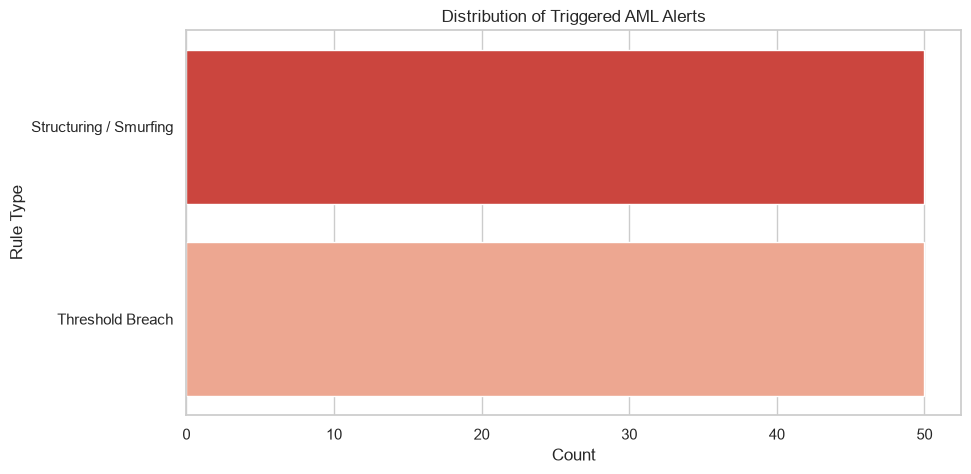

In [2]:
plt.figure(figsize=(10, 5))
sns.countplot(data=alerts_df, y='rule_triggered', palette='Reds_r')
plt.title('Distribution of Triggered AML Alerts')
plt.xlabel('Count')
plt.ylabel('Rule Type')
plt.show()


## 2. Credit Risk Tiers
How risky is our overall loan portfolio? We want most customers in 'Low Risk'.

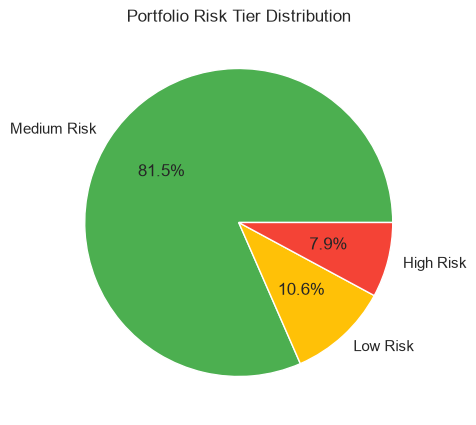

In [3]:
plt.figure(figsize=(8, 5))
tier_counts = risk_df['risk_tier'].value_counts()
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Portfolio Risk Tier Distribution')
plt.show()


## 3. Transaction Volumes
Are there specific days with massive spikes in transaction amounts?

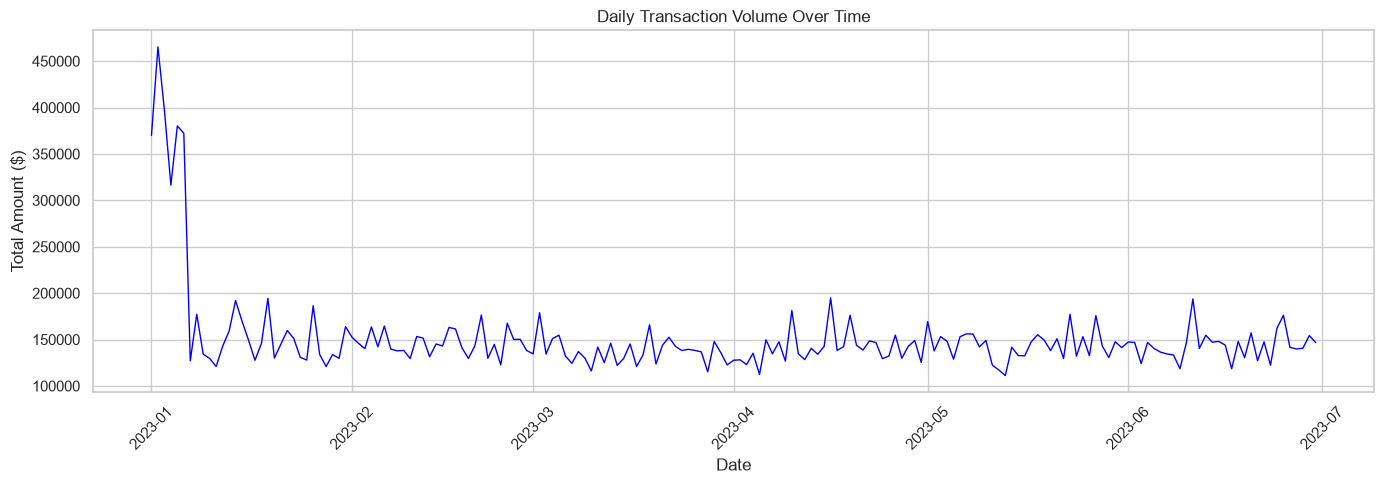

In [4]:
txns_df['timestamp'] = pd.to_datetime(txns_df['timestamp'])
daily_vol = txns_df.groupby(txns_df['timestamp'].dt.date)['amount'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_vol['timestamp'], daily_vol['amount'], color='blue', linewidth=1)
plt.title('Daily Transaction Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Model Performance (Credit Risk)
How well is our Logistic Regression model doing? We can look at the Confusion Matrix to see our True Positives vs False Positives.

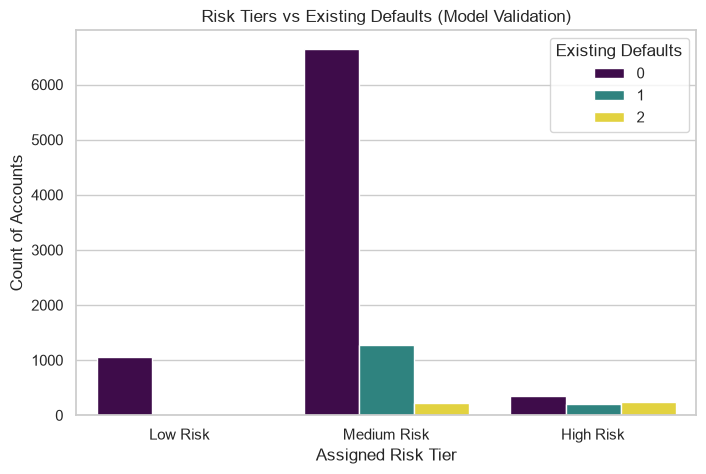

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# We will visualize the risk tiers vs existing defaults 
# as a proxy for how the model segregates risky behavior.
# First, we need to merge the risk scores back with our features
features_df = pd.read_csv('../data/processed/model_features.csv')
merged_risk_df = pd.merge(risk_df, features_df, on='account_id')

plt.figure(figsize=(8, 5))
sns.countplot(data=merged_risk_df, x='risk_tier', hue='existing_defaults', palette='viridis',
              order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Risk Tiers vs Existing Defaults (Model Validation)')
plt.xlabel('Assigned Risk Tier')
plt.ylabel('Count of Accounts')
plt.legend(title='Existing Defaults')
plt.show()
